# E-Visor v4 - entrenamiento LSTM multivariable multistep

Bloque 1: entorno

In [ ]:
import sys, os, json, time, warnings
import numpy as np
import pandas as pd
import tensorflow as tf

warnings.filterwarnings("ignore")
tf.get_logger().setLevel("ERROR")

print("python", sys.version.split()[0])
print("tensorflow", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU") or "sin GPU - cambia el entorno de ejecucion")

python 3.13.15
tensorflow 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Bloque 2: traer el repositorio y los datos

In [ ]:
import subprocess

URL_REPO = "https://github.com/danielagerena/E-Visor_Prediccion.git"
RUTA_REPO = "/content/E-Visor_Prediccion"
RAMA = "pipeline-produccion"   # aqui esta el CSV de febrero a agosto, no en main

if not os.path.isdir(RUTA_REPO):
    subprocess.run(["git", "clone", "-q", "--branch", RAMA, URL_REPO, RUTA_REPO], check=True)
else:
    # Si la carpeta quedo de una corrida anterior, puede estar en otra rama
    subprocess.run(["git", "-C", RUTA_REPO, "fetch", "-q", "origin", RAMA], check=True)
    subprocess.run(["git", "-C", RUTA_REPO, "checkout", "-q", RAMA], check=True)
    subprocess.run(["git", "-C", RUTA_REPO, "reset", "-q", "--hard", f"origin/{RAMA}"], check=True)

os.chdir(RUTA_REPO)
sys.path.insert(0, RUTA_REPO)
print("rama:", subprocess.run(["git", "-C", RUTA_REPO, "rev-parse", "--abbrev-ref", "HEAD"],
                              capture_output=True, text=True).stdout.strip())

CARPETA = "/content/evisor_v4"
os.makedirs(CARPETA, exist_ok=True)

RUTA_CSV = "datos/datos_preprocesados_10min.csv"
print("carpeta:", os.getcwd())
print("existe el csv:", os.path.isfile(RUTA_CSV))

rama: pipeline-produccion
carpeta: /content/E-Visor_Prediccion
existe el csv: True


Bloque 3: el modulo de funciones. Esta celda escribe el archivo evisor_lstm.py, que es el mismo que va al repositorio. No hay dos copias del codigo.

In [ ]:
%%writefile evisor_lstm.py
"""E-Visor - funciones de entrenamiento y evaluacion (LSTM multivariable multistep).

Todas las funciones son puras: no leen ni escriben variables globales. Eso
permite pegarlas tal cual en una celda de Colab hoy y copiarlas sin cambios a
src/modelo.py el dia que la configuracion pase a produccion.
"""
import numpy as np
import pandas as pd

# ----------------------------------------------------------------------------
# Constantes del proyecto
# ----------------------------------------------------------------------------
VARIABLES = ["activepower", "totalpowerfactor", "voltaje_promedio"]
PREFIJO = "SmartMeter_SM_"
FRECUENCIA = "10min"

PASOS_HORA = 6
PASOS_DIA = 144
PASOS_SEMANA = 1008

LARGO_ENTRADA = 288      # 48 horas que mira el modelo hacia atras
HORIZONTE = 144          # 24 horas que predice
PASO_MUESTREO = 6        # una ventana por hora al armar el entrenamiento
LIMITE_INTERPOLACION = 6  # huecos de hasta 1 hora se rellenan; los demas se dejan

PERIODOS_CLASE = [("2026-02-10", "2026-03-30"),   # Semana Santa: sin datos
                  ("2026-04-07", "2026-05-30"),
                  ("2026-07-14", "2026-09-01")]


# ----------------------------------------------------------------------------
# 1. Carga y organizacion de los datos
# ----------------------------------------------------------------------------
def cargar_datos(ruta_csv):
    """Lee el CSV preprocesado y agrega la columna 'bloque' sin el prefijo."""
    df = pd.read_csv(ruta_csv, parse_dates=["timestamp"])
    df["bloque"] = df["entity_id"].str.replace(PREFIJO, "", regex=False)
    return df.sort_values(["bloque", "timestamp"])


def tabla_bloque(df, bloque, limite_interp=LIMITE_INTERPOLACION):
    """Serie de un bloque sobre una rejilla continua de 10 minutos.

    Los huecos cortos se interpolan. Los largos se dejan como nulos: mas
    adelante se descartan las ventanas que los contengan, en vez de inventar
    datos.
    """
    d = df[df.bloque == bloque].set_index("timestamp").sort_index()
    idx = pd.date_range(d.index.min(), d.index.max(), freq=FRECUENCIA)
    d = d.reindex(idx)[VARIABLES]
    return d.interpolate(limit=limite_interp, limit_area="inside")


def mascara_clase(indice, periodos=PERIODOS_CLASE):
    """Marca que instantes caen dentro de un periodo de clase."""
    m = np.zeros(len(indice), dtype=bool)
    for a, b in periodos:
        m |= (indice >= pd.Timestamp(a)) & (indice < pd.Timestamp(b))
    return m


# ----------------------------------------------------------------------------
# 2. Construccion del dataset supervisado
# ----------------------------------------------------------------------------
def contexto_temporal(marcas):
    """Hora del dia y dia de la semana en seno y coseno.

    Se usan seno y coseno para que las 23:50 y las 00:00 queden cerca. Con un
    numero plano (0 a 23) el modelo veria un salto enorme a medianoche.
    """
    h = marcas.hour + marcas.minute / 60.0
    d = marcas.dayofweek
    return np.column_stack([
        np.sin(2 * np.pi * h / 24), np.cos(2 * np.pi * h / 24),
        np.sin(2 * np.pi * d / 7), np.cos(2 * np.pi * d / 7),
    ]).astype("float32")


def ventanas(tabla, origenes, largo_entrada=None, horizonte=None):
    """Arma las tres entradas y la salida para una lista de origenes.

    Para un origen t el modelo recibe:
      - pasado:  valores de t-largo_entrada+1 a t
      - semana:  los mismos instantes que va a predecir, pero 7 dias antes
      - contexto: hora y dia de la semana del origen
    y debe producir los valores de t+1 a t+horizonte.

    Todo lo que entra ya existia en el instante t. No hay fuga del futuro.
    """
    largo_entrada = LARGO_ENTRADA if largo_entrada is None else largo_entrada
    horizonte = HORIZONTE if horizonte is None else horizonte
    vals = tabla[VARIABLES].to_numpy("float32")
    origenes = np.asarray(origenes, dtype=int)

    i_pas = origenes[:, None] + np.arange(-largo_entrada + 1, 1)
    i_fut = origenes[:, None] + np.arange(1, horizonte + 1)
    i_sem = i_fut - PASOS_SEMANA

    x_pas, x_sem, y = vals[i_pas], vals[i_sem], vals[i_fut]
    x_ctx = contexto_temporal(tabla.index[origenes])

    completo = ~(np.isnan(x_pas).any((1, 2)) |
                 np.isnan(x_sem).any((1, 2)) |
                 np.isnan(y).any((1, 2)))
    return x_pas[completo], x_sem[completo], x_ctx[completo], y[completo], origenes[completo]


def origenes_validos(tabla, desde, hasta, paso, largo_entrada=None,
                     horizonte=None, solo_clase=True):
    """Posiciones de origen cuyo tramo a predecir cae en el rango pedido.

    Un origen es valido si hay suficiente historia atras (una semana) y si el
    tramo completo a predecir existe.
    """
    largo_entrada = LARGO_ENTRADA if largo_entrada is None else largo_entrada
    horizonte = HORIZONTE if horizonte is None else horizonte
    n = len(tabla)
    minimo = max(largo_entrada - 1, PASOS_SEMANA - 1)
    pos = np.arange(minimo, n - horizonte)

    inicio_objetivo = tabla.index[pos + 1]
    fin_objetivo = tabla.index[pos + horizonte]
    ok = (inicio_objetivo >= pd.Timestamp(desde)) & (fin_objetivo < pd.Timestamp(hasta))
    if solo_clase:
        ok &= mascara_clase(inicio_objetivo) & mascara_clase(fin_objetivo)
    return pos[ok][::paso]


def origenes_diarios(tabla, desde, hasta):
    """Un origen por dia, de forma que cada prediccion cubra de 00:00 a 23:50."""
    dias = pd.date_range(pd.Timestamp(desde), pd.Timestamp(hasta), freq="D")
    posiciones = []
    for d in dias:
        if d not in tabla.index:
            continue
        p = tabla.index.get_loc(d) - 1
        if p < max(LARGO_ENTRADA - 1, PASOS_SEMANA - 1):
            continue
        if p + HORIZONTE >= len(tabla):
            continue
        posiciones.append(p)
    return np.array(posiciones, dtype=int)


# ----------------------------------------------------------------------------
# 3. Escalamiento por bloque
# ----------------------------------------------------------------------------
def limites(tabla, hasta_entrenamiento):
    """Minimo y maximo de cada variable, calculados solo con datos de entrenamiento."""
    d = tabla.loc[tabla.index < pd.Timestamp(hasta_entrenamiento), VARIABLES]
    mn = d.min().to_numpy("float32")
    mx = d.max().to_numpy("float32")
    rango = np.where(mx - mn < 1e-9, 1.0, mx - mn).astype("float32")
    return mn, rango


def escalar(a, mn, rango):
    """Lleva los valores al rango -1 a 1 usando los limites del bloque."""
    return 2 * (a - mn) / rango - 1


def desescalar(a, mn, rango):
    return (a + 1) / 2 * rango + mn


# ----------------------------------------------------------------------------
# 4. El modelo
# ----------------------------------------------------------------------------
def construir_modelo(n_contexto, unidades=128, densa=256, dropout=0.2,
                     largo_entrada=None, horizonte=None,
                     n_vars=len(VARIABLES), tasa=1e-3):
    """LSTM multivariable multistep con tres entradas.

    Una rama lee las ultimas 48 horas, otra lee las mismas horas de la semana
    pasada, y el contexto dice que hora y que dia se esta prediciendo (y, en
    modo global, de que bloque se trata).
    """
    from tensorflow.keras import Input, Model
    from tensorflow.keras.layers import LSTM, Dense, Dropout, Concatenate, Reshape
    from tensorflow.keras.optimizers import Adam

    largo_entrada = LARGO_ENTRADA if largo_entrada is None else largo_entrada
    horizonte = HORIZONTE if horizonte is None else horizonte

    ent_pas = Input(shape=(largo_entrada, n_vars), name="pasado")
    ent_sem = Input(shape=(horizonte, n_vars), name="semana")
    ent_ctx = Input(shape=(n_contexto,), name="contexto")

    h1 = LSTM(unidades)(ent_pas)
    h2 = LSTM(unidades // 2)(ent_sem)
    z = Concatenate()([h1, h2, ent_ctx])
    z = Dense(densa, activation="relu")(z)
    z = Dropout(dropout)(z)
    salida = Reshape((horizonte, n_vars))(Dense(horizonte * n_vars)(z))

    modelo = Model([ent_pas, ent_sem, ent_ctx], salida)
    # Error absoluto: es la misma familia del WAPE con el que se mide.
    # Entrenar con error cuadratico seria apuntarle a un blanco distinto.
    modelo.compile(optimizer=Adam(learning_rate=tasa), loss="mae")
    return modelo


def fijar_semilla(semilla):
    import random, os
    import tensorflow as tf
    os.environ["PYTHONHASHSEED"] = str(semilla)
    random.seed(semilla)
    np.random.seed(semilla)
    tf.random.set_seed(semilla)


# ----------------------------------------------------------------------------
# 5. Metricas
# ----------------------------------------------------------------------------
def wape(real, pred):
    """Error total dividido entre el consumo total. No se dispara cerca de cero."""
    real, pred = np.asarray(real, float), np.asarray(pred, float)
    m = ~(np.isnan(real) | np.isnan(pred))
    total = np.sum(np.abs(real[m]))
    return 100 * np.sum(np.abs(real[m] - pred[m])) / total if total > 0 else np.nan


def rmse(real, pred):
    real, pred = np.asarray(real, float), np.asarray(pred, float)
    m = ~(np.isnan(real) | np.isnan(pred))
    return float(np.sqrt(np.mean((real[m] - pred[m]) ** 2)))


def tabla_metricas(detalle):
    """WAPE y RMSE por bloque y variable a partir del detalle punto a punto."""
    filas = []
    for (b, v), g in detalle.groupby(["bloque", "variable"]):
        filas.append({"bloque": b, "variable": v,
                      "wape_modelo": wape(g.real, g.pred),
                      "wape_ingenuo": wape(g.real, g.ingenuo),
                      "rmse_modelo": rmse(g.real, g.pred)})
    return pd.DataFrame(filas)


def error_por_horizonte(detalle, variable="activepower"):
    """Como crece el error a medida que la prediccion se aleja."""
    d = detalle[detalle.variable == variable]
    return d.groupby("paso").apply(
        lambda g: pd.Series({"wape_modelo": wape(g.real, g.pred),
                             "wape_ingenuo": wape(g.real, g.ingenuo)}))


# ----------------------------------------------------------------------------
# 6. Armado de los conjuntos y entrenamiento
# ----------------------------------------------------------------------------
RANGOS_TREN = [("2026-02-10", "2026-05-16"), ("2026-07-14", "2026-08-01")]
RANGO_VAL = ("2026-05-16", "2026-05-30")
RANGO_PRUEBA = ("2026-08-01", "2026-09-01")


def preparar_tablas(df, bloques, hasta_entrenamiento=RANGO_PRUEBA[0]):
    """Una tabla y unos limites de escalado por bloque."""
    tablas, lims = {}, {}
    for b in bloques:
        t = tabla_bloque(df, b)
        tablas[b] = t
        lims[b] = limites(t, hasta_entrenamiento)
    return tablas, lims


def armar_conjunto(tablas, lims, bloques, rangos, paso, indice_bloque=None):
    """Junta las ventanas de los bloques pedidos, ya escaladas.

    Si indice_bloque es None se entrena por bloque (el contexto solo lleva
    calendario). Si trae el diccionario de posiciones, se entrena un modelo
    global y el contexto lleva ademas la identidad del bloque.
    """
    P, S, C, Y, ORIG, BLQ = [], [], [], [], [], []
    for b in bloques:
        t, (mn, rango) = tablas[b], lims[b]
        for desde, hasta in rangos:
            pos = origenes_validos(t, desde, hasta, paso)
            if len(pos) == 0:
                continue
            p, s, c, y, orig = ventanas(t, pos)
            if len(y) == 0:
                continue
            P.append(escalar(p, mn, rango))
            S.append(escalar(s, mn, rango))
            Y.append(escalar(y, mn, rango))
            if indice_bloque is not None:
                ident = np.zeros((len(c), len(indice_bloque)), "float32")
                ident[:, indice_bloque[b]] = 1.0
                c = np.hstack([c, ident])
            C.append(c)
            ORIG.append(t.index[orig])
            BLQ.append(np.repeat(b, len(y)))
    if not Y:
        return None
    return {"pasado": np.concatenate(P), "semana": np.concatenate(S),
            "contexto": np.concatenate(C), "y": np.concatenate(Y),
            "origen": np.concatenate(ORIG), "bloque": np.concatenate(BLQ)}


def entrenar(conj_tren, conj_val, semilla, epocas=60, lote=256, paciencia=8,
             unidades=128, verbose=0):
    """Entrena una red y devuelve el modelo y su historia."""
    from tensorflow.keras.callbacks import EarlyStopping
    fijar_semilla(semilla)
    modelo = construir_modelo(n_contexto=conj_tren["contexto"].shape[1],
                              unidades=unidades)
    parada = EarlyStopping(monitor="val_loss", patience=paciencia,
                           restore_best_weights=True)
    historia = modelo.fit(
        x={"pasado": conj_tren["pasado"], "semana": conj_tren["semana"],
           "contexto": conj_tren["contexto"]},
        y=conj_tren["y"],
        validation_data=({"pasado": conj_val["pasado"], "semana": conj_val["semana"],
                          "contexto": conj_val["contexto"]}, conj_val["y"]),
        epochs=epocas, batch_size=lote, callbacks=[parada], verbose=verbose)
    return modelo, historia


def evaluar(modelo, tablas, lims, bloques, rango=RANGO_PRUEBA, indice_bloque=None,
            cada_horas=None):
    """Una prediccion por dia. Devuelve el detalle punto a punto.

    La columna 'ingenuo' es la regla trivial: el valor de hace una semana. Sale
    de la misma ventana que recibe el modelo, asi que los dos se miden sobre
    exactamente los mismos instantes.
    """
    filas = []
    for b in bloques:
        t, (mn, rango_esc) = tablas[b], lims[b]
        if cada_horas is None:
            pos = origenes_diarios(t, rango[0], pd.Timestamp(rango[1]) - pd.Timedelta(days=1))
        else:
            pos = origenes_repartidos(t, rango[0], rango[1], cada_horas)
        if len(pos) == 0:
            continue
        p, s, c, y, orig = ventanas(t, pos)
        if len(y) == 0:
            continue
        if indice_bloque is not None:
            ident = np.zeros((len(c), len(indice_bloque)), "float32")
            ident[:, indice_bloque[b]] = 1.0
            c = np.hstack([c, ident])
        pred = modelo.predict({"pasado": escalar(p, mn, rango_esc),
                               "semana": escalar(s, mn, rango_esc),
                               "contexto": c}, verbose=0)
        pred = desescalar(pred, mn, rango_esc)
        n, h, v = y.shape
        pasos = np.tile(np.arange(1, h + 1), n)
        for j, var in enumerate(VARIABLES):
            filas.append(pd.DataFrame({
                "bloque": b, "variable": var, "paso": pasos,
                "origen": np.repeat(t.index[orig], h),
                "real": y[:, :, j].ravel(),
                "pred": pred[:, :, j].ravel(),
                "ingenuo": s[:, :, j].ravel()}))
    return pd.concat(filas, ignore_index=True)


def comparar_pareado(tabla_a, tabla_b, variable="activepower",
                     nombre_a="A", nombre_b="B"):
    """Prueba de Wilcoxon sobre el WAPE por bloque.

    Cada bloque aporta una observacion, no cada punto de la serie. Los errores
    de instantes seguidos estan correlacionados y usarlos como si fueran
    independientes infla la significancia.
    """
    from scipy.stats import wilcoxon
    a = tabla_a[tabla_a.variable == variable].set_index("bloque").wape_modelo
    b = tabla_b[tabla_b.variable == variable].set_index("bloque").wape_modelo
    comun = a.index.intersection(b.index)
    a, b = a.loc[comun], b.loc[comun]
    est, p = wilcoxon(a, b)
    return pd.DataFrame({nombre_a: a, nombre_b: b, "diferencia": a - b}), est, p


# ----------------------------------------------------------------------------
# 7. Guardado de artefactos
# ----------------------------------------------------------------------------
def guardar_artefactos(carpeta, nombre, modelo, lims, indice_bloque, ficha):
    """Guarda el modelo, los limites de escalado y la ficha de la version.

    Sin los limites el modelo no sirve: predice en el rango -1 a 1 y hay que
    devolverlo a vatios. Sin la ficha, dentro de seis meses nadie va a poder
    explicar de donde salio un numero.
    """
    import json, os
    os.makedirs(carpeta, exist_ok=True)
    modelo.save(f"{carpeta}/{nombre}.keras")
    np.savez(f"{carpeta}/{nombre}_limites.npz",
             **{f"{b}_mn": v[0] for b, v in lims.items()},
             **{f"{b}_rango": v[1] for b, v in lims.items()})
    with open(f"{carpeta}/{nombre}_ficha.json", "w", encoding="utf-8") as f:
        json.dump({**ficha, "indice_bloque": indice_bloque}, f,
                  indent=2, ensure_ascii=False)


def cargar_artefactos(carpeta, nombre):
    import json
    from tensorflow.keras.models import load_model
    modelo = load_model(f"{carpeta}/{nombre}.keras")
    z = np.load(f"{carpeta}/{nombre}_limites.npz")
    bloques = sorted({k.rsplit("_", 1)[0] for k in z.files})
    lims = {b: (z[f"{b}_mn"], z[f"{b}_rango"]) for b in bloques}
    with open(f"{carpeta}/{nombre}_ficha.json", encoding="utf-8") as f:
        ficha = json.load(f)
    return modelo, lims, ficha


# ----------------------------------------------------------------------------
# 8. Evaluacion con origenes repartidos y esquema hibrido
# ----------------------------------------------------------------------------
def origenes_repartidos(tabla, desde, hasta, cada_horas=4, solo_clase=True):
    """Origenes repartidos a lo largo del dia, no solo a medianoche.

    Con un origen diario a las 23:50, el paso h cae siempre a la misma hora del
    dia: el paso 1 son las 00:00 y el paso 144 las 23:50. La curva de error
    termina midiendo hora del dia y no distancia de pronostico. Repartiendo los
    origenes las dos cosas se separan.
    """
    return origenes_validos(tabla, desde, hasta, int(cada_horas * PASOS_HORA),
                            solo_clase=solo_clase)


def elegir_hibrido(detalle_validacion, variable="activepower"):
    """Decide por bloque si conviene el modelo o la regla trivial.

    Se llama con el detalle del conjunto de VALIDACION. Elegir mirando la
    prueba infla el numero que se reporta despues.
    """
    t = tabla_metricas(detalle_validacion)
    t = t[t.variable == variable]
    return {r.bloque: ("modelo" if r.wape_modelo < r.wape_ingenuo else "trivial")
            for r in t.itertuples()}


def aplicar_hibrido(detalle, eleccion):
    """Sustituye la prediccion por la regla trivial en los bloques elegidos."""
    d = detalle.copy()
    usar_trivial = d.bloque.map(eleccion).eq("trivial").fillna(False)
    d.loc[usar_trivial, "pred"] = d.loc[usar_trivial, "ingenuo"]
    return d


# ----------------------------------------------------------------------------
# 9. Validacion cruzada de ventana expansiva
# ----------------------------------------------------------------------------
def correr_pliegue(tablas, bloques, pliegue, paso, indice_bloque, semilla, **kw):
    """Entrena y evalua un pliegue completo.

    Los limites de escalado se recalculan con datos anteriores a la prueba de
    ESTE pliegue. Si se reutilizaran los del experimento principal, el pliegue
    estaria mirando informacion posterior a su propia prueba.
    """
    lims = {b: limites(tablas[b], pliegue["prueba"][0]) for b in bloques}
    tren = armar_conjunto(tablas, lims, bloques, pliegue["tren"], paso, indice_bloque)
    val = armar_conjunto(tablas, lims, bloques, [pliegue["val"]], paso, indice_bloque)
    if tren is None or val is None:
        return None, None, 0
    modelo, hist = entrenar(tren, val, semilla=semilla, **kw)
    det = evaluar(modelo, tablas, lims, bloques, pliegue["prueba"], indice_bloque)
    return modelo, det, len(hist.history["loss"])

Overwriting evisor_lstm.py


Bloque 4: configuracion del experimento. Es el unico sitio donde se cambian fechas e hiperparametros.

In [ ]:
import importlib
import evisor_lstm as E
importlib.reload(E)

# Calendario academico. Fin exclusivo.
# Del 30 de marzo al 6 de abril no hay datos en ningun medidor: mantenimiento
# de Semana Santa. Se trata como un tramo aparte, no como un salto en la serie.
E.PERIODOS_CLASE = [("2026-02-10", "2026-03-30"),
                    ("2026-04-07", "2026-05-30"),
                    ("2026-07-14", "2026-09-01")]

# Particion. La prueba es agosto y no se toca para nada mas.
RANGOS_TREN  = [("2026-02-10", "2026-03-30"), ("2026-04-07", "2026-05-16"),
                ("2026-07-14", "2026-08-01")]
RANGO_VAL    = ("2026-05-16", "2026-05-30")
RANGO_PRUEBA = ("2026-08-01", "2026-09-01")

# Ventanas
E.LARGO_ENTRADA = 288    # 48 horas de historia
E.HORIZONTE     = 144    # 24 horas a predecir
PASO_MUESTREO   = 6      # una ventana por hora al entrenar

# Entrenamiento
SEMILLAS  = [42, 7, 123]
EPOCAS    = 60
LOTE      = 256
UNIDADES  = 128
PACIENCIA = 8

# Medidor averiado: entra al entrenamiento pero se reporta aparte
BLOQUES_MARCADOS = ["B8_CPA"]

print("entrenamiento:", RANGOS_TREN)
print("validacion:   ", RANGO_VAL)
print("prueba:       ", RANGO_PRUEBA)

entrenamiento: [('2026-02-10', '2026-03-30'), ('2026-04-07', '2026-05-16'), ('2026-07-14', '2026-08-01')]
validacion:    ('2026-05-16', '2026-05-30')
prueba:        ('2026-08-01', '2026-09-01')


Bloque 5: cargar datos y preparar una tabla por bloque

In [ ]:
df = E.cargar_datos(RUTA_CSV)
bloques = sorted(df.bloque.unique())
print(f"{len(df):,} filas | {len(bloques)} bloques | "
      f"{df.timestamp.min()} -> {df.timestamp.max()}")

# Verificacion: sin datos de agosto no hay conjunto de prueba y todo lo que
# siga sera ruido. Mejor parar aqui que entregar numeros vacios.
if df.timestamp.max() < pd.Timestamp(RANGO_PRUEBA[1]) - pd.Timedelta(days=2):
    raise SystemExit(
        f"Los datos llegan hasta {df.timestamp.max()} y la prueba necesita "
        f"hasta {RANGO_PRUEBA[1]}. Sube al repositorio el CSV actualizado.")

tablas, limites = E.preparar_tablas(df, bloques, hasta_entrenamiento=RANGO_PRUEBA[0])
indice_bloque = {b: i for i, b in enumerate(bloques)}

# Cuantas ventanas sobreviven por bloque. Una cifra muy baja aqui significa
# huecos de datos, no un problema del modelo.
resumen = []
for b in bloques:
    pos = np.concatenate([E.origenes_validos(tablas[b], a, z, PASO_MUESTREO)
                          for a, z in RANGOS_TREN])
    _, _, _, y, _ = E.ventanas(tablas[b], pos)
    resumen.append({"bloque": b, "posibles": len(pos), "completas": len(y),
                    "descartadas_%": round(100 * (1 - len(y) / max(len(pos), 1)), 1)})
print(pd.DataFrame(resumen).to_string(index=False))

462,911 filas | 16 bloques | 2026-02-10 10:20:00 -> 2026-08-31 14:30:00
  bloque  posibles  completas  descartadas_%
 B10_ARQ      2272       2041           10.2
B12_DERE      2272       2041           10.2
B15_BIBL      1787       1556           12.9
B17_POLI      2272       2041           10.2
B18_PARQ      2272       2041           10.2
 B3_RECT      2272       2041           10.2
 B4_PRIM      2272       2041           10.2
 B5_BACH      2272       1939           14.7
 B7_CTIC      2272       2041           10.2
  B7_TAC      2272       2041           10.2
   B8_AA      2272       2041           10.2
  B8_CPA      2272       2041           10.2
 B8_LABS      2272       2041           10.2
 B9_SFA1      2272       2041           10.2
 B9_SFA2      2272       2041           10.2
ECOVILLA      2272       1943           14.5


Bloque 6: la barra a superar. Es la regla trivial: copiar lo que paso hace una semana.

In [ ]:
detalle_ingenuo = []
for b in bloques:
    pos = E.origenes_diarios(tablas[b], RANGO_PRUEBA[0],
                             pd.Timestamp(RANGO_PRUEBA[1]) - pd.Timedelta(days=1))
    _, s, _, y, orig = E.ventanas(tablas[b], pos)
    if len(y) == 0:
        continue
    n, h, _ = y.shape
    for j, var in enumerate(E.VARIABLES):
        detalle_ingenuo.append(pd.DataFrame({
            "bloque": b, "variable": var,
            "real": y[:, :, j].ravel(), "pred": s[:, :, j].ravel()}))
detalle_ingenuo = pd.concat(detalle_ingenuo, ignore_index=True)

BARRA = {}
print("BARRA A SUPERAR (agosto, WAPE %)")
for var in E.VARIABLES:
    d = detalle_ingenuo[detalle_ingenuo.variable == var]
    BARRA[var] = E.wape(d.real, d.pred)
    print(f"  {var:<18} {BARRA[var]:6.2f}")

V2_GLOBAL = {"activepower": 26.87, "totalpowerfactor": 4.14, "voltaje_promedio": 0.49}
print("\nreferencia modelo global v2, misma ventana:", V2_GLOBAL)

BARRA A SUPERAR (agosto, WAPE %)
  activepower         29.25
  totalpowerfactor     6.63
  voltaje_promedio     0.54

referencia modelo global v2, misma ventana: {'activepower': 26.87, 'totalpowerfactor': 4.14, 'voltaje_promedio': 0.49}


Bloque 7: experimento A, un solo modelo global para los 16 bloques

In [ ]:
tren_g = E.armar_conjunto(tablas, limites, bloques, RANGOS_TREN, PASO_MUESTREO, indice_bloque)
val_g  = E.armar_conjunto(tablas, limites, bloques, [RANGO_VAL], PASO_MUESTREO, indice_bloque)

print("ventanas de entrenamiento:", tren_g["pasado"].shape[0])
print("ventanas de validacion:   ", val_g["pasado"].shape[0])
print("memoria:", round((tren_g["pasado"].nbytes + tren_g["semana"].nbytes) / 1e6, 1), "MB")

modelos_g, metricas_g, detalles_g = {}, {}, {}
for s in SEMILLAS:
    t0 = time.time()
    m, hist = E.entrenar(tren_g, val_g, semilla=s, epocas=EPOCAS, lote=LOTE,
                         paciencia=PACIENCIA, unidades=UNIDADES, verbose=0)
    det = E.evaluar(m, tablas, limites, bloques, RANGO_PRUEBA, indice_bloque)
    tab = E.tabla_metricas(det)
    modelos_g[s], metricas_g[s], detalles_g[s] = m, tab, det
    ap = det[det.variable == "activepower"]
    print(f"  semilla {s}: {len(hist.history['loss'])} epocas, "
          f"WAPE {E.wape(ap.real, ap.pred):6.2f} %  ({(time.time()-t0)/60:.1f} min)")

ventanas de entrenamiento: 31971
ventanas de validacion:    5008
memoria: 165.7 MB
  semilla 42: 45 epocas, WAPE  24.52 %  (3.4 min)
  semilla 7: 38 epocas, WAPE  24.80 %  (2.9 min)
  semilla 123: 40 epocas, WAPE  24.14 %  (3.1 min)


Bloque 8: experimento B, un modelo por bloque. Mismo codigo, misma particion, misma metrica. Lo unico que cambia es que cada modelo solo ve su propio bloque.

In [ ]:
CORRER_POR_BLOQUE = True

modelos_b, detalles_b = {}, {}
if CORRER_POR_BLOQUE:
    for s in SEMILLAS:
        t0, dets = time.time(), []
        for b in bloques:
            tr = E.armar_conjunto(tablas, limites, [b], RANGOS_TREN, PASO_MUESTREO, None)
            vl = E.armar_conjunto(tablas, limites, [b], [RANGO_VAL], PASO_MUESTREO, None)
            if tr is None or vl is None:
                print(f"    {b}: sin ventanas suficientes, se omite")
                continue
            mb, _ = E.entrenar(tr, vl, semilla=s, epocas=EPOCAS, lote=64,
                               paciencia=PACIENCIA, unidades=UNIDADES, verbose=0)
            modelos_b[(s, b)] = mb
            dets.append(E.evaluar(mb, tablas, limites, [b], RANGO_PRUEBA, None))
        detalles_b[s] = pd.concat(dets, ignore_index=True)
        ap = detalles_b[s][detalles_b[s].variable == "activepower"]
        print(f"  semilla {s}: WAPE {E.wape(ap.real, ap.pred):6.2f} %  "
              f"({(time.time()-t0)/60:.1f} min)")

  semilla 42: WAPE  26.94 %  (7.6 min)
  semilla 7: WAPE  27.67 %  (7.2 min)
  semilla 123: WAPE  26.89 %  (7.0 min)


Bloque 9: comparacion. Primero el resumen, despues la prueba estadistica sobre los 16 bloques y la curva de error contra el horizonte.

In [ ]:
def resumen_semillas(detalles, etiqueta, excluir=()):
    filas = []
    for var in E.VARIABLES:
        vals = []
        for s, det in detalles.items():
            d = det[(det.variable == var) & (~det.bloque.isin(excluir))]
            vals.append(E.wape(d.real, d.pred))
        filas.append({"modelo": etiqueta, "variable": var,
                      "wape_medio": round(float(np.mean(vals)), 2),
                      "wape_desv": round(float(np.std(vals)), 2)})
    return pd.DataFrame(filas)

resumen = [resumen_semillas(detalles_g, "global", BLOQUES_MARCADOS)]
if detalles_b:
    resumen.append(resumen_semillas(detalles_b, "por_bloque", BLOQUES_MARCADOS))
resumen = pd.concat(resumen, ignore_index=True)
resumen["regla_trivial"] = resumen.variable.map(BARRA).round(2)
resumen["v2_global"] = resumen.variable.map(V2_GLOBAL)
print("WAPE % sobre agosto, promedio de", len(SEMILLAS), "semillas, sin", BLOQUES_MARCADOS)
print(resumen.to_string(index=False))
resumen.to_csv(f"{CARPETA}/resumen_v4.csv", index=False)

WAPE % sobre agosto, promedio de 3 semillas, sin ['B8_CPA']
    modelo         variable  wape_medio  wape_desv  regla_trivial  v2_global
    global      activepower       24.45       0.27          29.25      26.87
    global totalpowerfactor        2.40       0.02           6.63       4.14
    global voltaje_promedio        0.43       0.00           0.54       0.49
por_bloque      activepower       27.13       0.36          29.25      26.87
por_bloque totalpowerfactor        2.87       0.18           6.63       4.14
por_bloque voltaje_promedio        0.44       0.00           0.54       0.49


In [ ]:
# Prueba pareada sobre los 16 bloques. Una observacion por bloque, no por punto:
# los errores de instantes seguidos estan correlacionados.
if detalles_b:
    s0 = SEMILLAS[0]
    tab_g = E.tabla_metricas(detalles_g[s0])
    tab_b = E.tabla_metricas(detalles_b[s0])
    cmp_, est, p = E.comparar_pareado(tab_g, tab_b, "activepower", "global", "por_bloque")
    print(cmp_.round(2).to_string())
    print(f"\nWilcoxon pareado sobre {len(cmp_)} bloques: p = {p:.4f}")
    print("p < 0.05 significa que la diferencia entre los dos enfoques no es casualidad.")

          global  por_bloque  diferencia
bloque                                  
B10_ARQ    33.31       37.31       -4.00
B12_DERE   26.14       25.69        0.45
B15_BIBL   26.36       29.07       -2.71
B17_POLI   43.69       41.96        1.74
B18_PARQ   20.52       20.35        0.17
B3_RECT    29.23       33.21       -3.97
B4_PRIM    22.94       25.03       -2.09
B5_BACH    24.09       24.39       -0.30
B7_CTIC     7.30        7.41       -0.12
B7_TAC     25.20       34.16       -8.97
B8_AA      73.20       75.56       -2.36
B8_CPA    217.29      242.29      -25.00
B8_LABS    20.21       21.11       -0.90
B9_SFA1    17.38       19.48       -2.11
B9_SFA2    36.86       44.09       -7.24
ECOVILLA   47.52       50.88       -3.35

Wilcoxon pareado sobre 16 bloques: p = 0.0021
p < 0.05 significa que la diferencia entre los dos enfoques no es casualidad.


In [ ]:
# Contra la regla trivial, bloque por bloque
s0 = SEMILLAS[0]
tab = E.tabla_metricas(detalles_g[s0])
ap = tab[tab.variable == "activepower"].set_index("bloque")
ap = ap[["wape_modelo", "wape_ingenuo"]].round(1)
ap["ventaja_%"] = (100 * (ap.wape_ingenuo - ap.wape_modelo) / ap.wape_ingenuo).round(1)
ap["gana"] = np.where(ap.wape_modelo < ap.wape_ingenuo, "si", "no")
print(ap.sort_values("ventaja_%", ascending=False).to_string())
print(f"\nbloques donde el modelo gana: {(ap.gana == 'si').sum()} de {len(ap)}")
ap.to_csv(f"{CARPETA}/por_bloque_v4.csv")

          wape_modelo  wape_ingenuo  ventaja_% gana
bloque                                             
B17_POLI         43.7          66.2       34.0   si
B10_ARQ          33.3          47.7       30.2   si
B9_SFA2          36.9          48.7       24.2   si
B4_PRIM          22.9          27.7       17.3   si
B8_LABS          20.2          24.4       17.2   si
B9_SFA1          17.4          21.0       17.1   si
ECOVILLA         47.5          57.0       16.7   si
B18_PARQ         20.5          24.5       16.3   si
B7_CTIC           7.3           8.7       16.1   si
B7_TAC           25.2          27.8        9.4   si
B5_BACH          24.1          26.0        7.3   si
B3_RECT          29.2          30.8        5.2   si
B8_AA            73.2          76.6        4.4   si
B15_BIBL         26.4          25.2       -4.8   no
B12_DERE         26.1          23.5      -11.1   no
B8_CPA          217.3         126.0      -72.5   no

bloques donde el modelo gana: 13 de 16


  +  0.2 h   modelo  10.36 %   trivial  27.49 %
  +  3.0 h   modelo  16.65 %   trivial  25.21 %
  +  6.0 h   modelo  23.89 %   trivial  24.53 %
  + 12.0 h   modelo  24.61 %   trivial  27.78 %
  + 18.0 h   modelo  29.80 %   trivial  30.97 %
  + 24.0 h   modelo  19.99 %   trivial  37.12 %


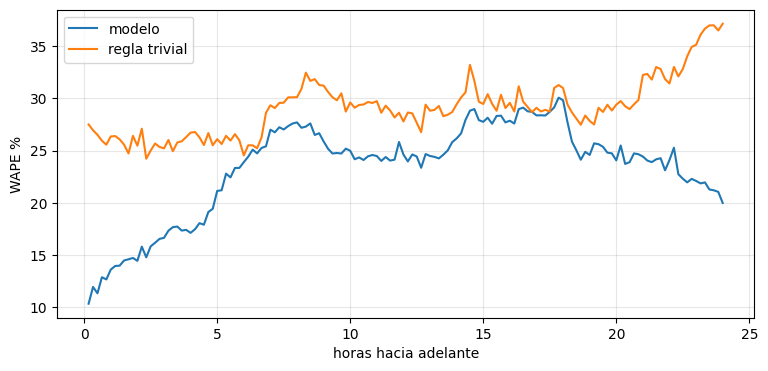

In [ ]:
# Como crece el error a medida que la prediccion se aleja.
# Sirve para el tablero: muestra cuanta confianza pierde cada hora.
curva = E.error_por_horizonte(detalles_g[SEMILLAS[0]], "activepower")
for paso in [1, 18, 36, 72, 108, 144]:
    f = curva.loc[paso]
    print(f"  +{paso*10/60:5.1f} h   modelo {f.wape_modelo:6.2f} %   "
          f"trivial {f.wape_ingenuo:6.2f} %")
curva.to_csv(f"{CARPETA}/error_por_horizonte.csv")

import matplotlib.pyplot as plt
plt.figure(figsize=(9, 4))
plt.plot(curva.index * 10 / 60, curva.wape_modelo, label="modelo")
plt.plot(curva.index * 10 / 60, curva.wape_ingenuo, label="regla trivial")
plt.xlabel("horas hacia adelante")
plt.ylabel("WAPE %")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Bloque 10: guardar la version ganadora y descargarla

origenes evaluados por bloque: 123

error segun que tan lejos se predice
  +  0.2 h   modelo   9.78 %   trivial  29.88 %
  +  3.0 h   modelo  18.92 %   trivial  29.29 %
  +  6.0 h   modelo  21.95 %   trivial  28.56 %
  + 12.0 h   modelo  24.42 %   trivial  28.91 %
  + 18.0 h   modelo  25.47 %   trivial  29.93 %
  + 24.0 h   modelo  26.98 %   trivial  33.39 %


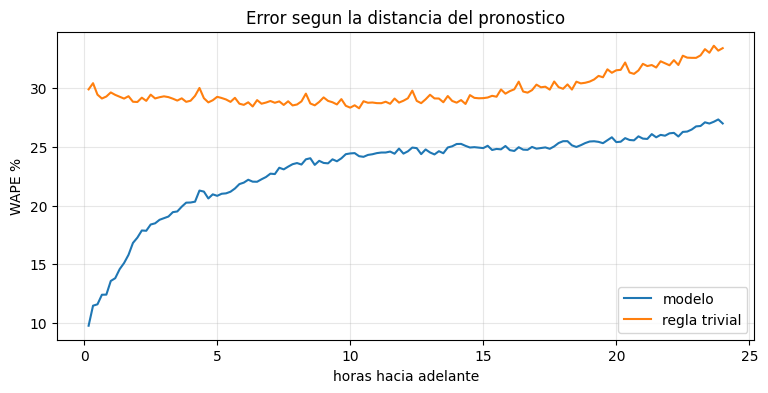

In [ ]:
# La curva del bloque 9 no mide distancia de pronostico: como todas las
# predicciones parten de medianoche, el paso h cae siempre a la misma hora del
# dia. Aqui se reparten los origenes cada 4 horas para separar las dos cosas.
# No hay que reentrenar nada.
s0 = SEMILLAS[0]
det_rep = E.evaluar(modelos_g[s0], tablas, limites, bloques, RANGO_PRUEBA,
                    indice_bloque, cada_horas=4)
curva_real = E.error_por_horizonte(det_rep, "activepower")

print("origenes evaluados por bloque:", len(det_rep) // (len(bloques) * 3 * E.HORIZONTE))
print("\nerror segun que tan lejos se predice")
for paso in [1, 18, 36, 72, 108, 144]:
    f = curva_real.loc[paso]
    print(f"  +{paso*10/60:5.1f} h   modelo {f.wape_modelo:6.2f} %   "
          f"trivial {f.wape_ingenuo:6.2f} %")
curva_real.to_csv(f"{CARPETA}/error_por_horizonte_real.csv")

import matplotlib.pyplot as plt
plt.figure(figsize=(9, 4))
plt.plot(curva_real.index * 10 / 60, curva_real.wape_modelo, label="modelo")
plt.plot(curva_real.index * 10 / 60, curva_real.wape_ingenuo, label="regla trivial")
plt.xlabel("horas hacia adelante")
plt.ylabel("WAPE %")
plt.title("Error segun la distancia del pronostico")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Bloque 11: esquema hibrido. Para los bloques donde el modelo no le gana a la regla trivial se usa la regla. La eleccion se hace sobre la validacion, nunca sobre agosto.

In [ ]:
det_val = E.evaluar(modelos_g[s0], tablas, limites, bloques, RANGO_VAL,
                    indice_bloque, cada_horas=4)
eleccion = E.elegir_hibrido(det_val)

usan_trivial = [b for b, v in eleccion.items() if v == "trivial"]
print("bloques que usarian la regla trivial:", usan_trivial or "ninguno")

det_hib = E.aplicar_hibrido(detalles_g[s0], eleccion)
print(f"\n{'variable':<20}{'global':>10}{'hibrido':>10}{'trivial':>10}")
for var in E.VARIABLES:
    a = detalles_g[s0][detalles_g[s0].variable == var]
    h = det_hib[det_hib.variable == var]
    print(f"{var:<20}{E.wape(a.real, a.pred):>10.2f}{E.wape(h.real, h.pred):>10.2f}"
          f"{BARRA[var]:>10.2f}")

# Cuantos bloques le ganan a la trivial con y sin hibrido
for etiqueta, d in [("global", detalles_g[s0]), ("hibrido", det_hib)]:
    t = E.tabla_metricas(d)
    t = t[t.variable == "activepower"]
    print(f"  {etiqueta}: {(t.wape_modelo <= t.wape_ingenuo).sum()} de {len(t)} bloques")

bloques que usarian la regla trivial: ninguno

variable                global   hibrido   trivial
activepower              24.52     24.52     29.25
totalpowerfactor          3.78      3.78      6.63
voltaje_promedio          0.43      0.43      0.54
  global: 13 de 16 bloques
  hibrido: 13 de 16 bloques


Bloque 12: validacion cruzada de ventana expansiva. Es para el informe: muestra que el resultado no es casualidad de un solo mes. No cambia el modelo.

In [ ]:
CORRER_VALIDACION_CRUZADA = True   # unos 10 minutos con una semilla

PLIEGUES = [
    {"nombre": "P1",
     "tren": [("2026-02-10", "2026-03-30"), ("2026-04-07", "2026-04-20")],
     "val": ("2026-04-20", "2026-05-04"),
     "prueba": ("2026-05-04", "2026-05-18")},
    {"nombre": "P2",
     "tren": [("2026-02-10", "2026-03-30"), ("2026-04-07", "2026-05-04")],
     "val": ("2026-05-04", "2026-05-16"),
     "prueba": ("2026-05-16", "2026-05-30")},
    {"nombre": "P3",
     "tren": [("2026-02-10", "2026-03-30"), ("2026-04-07", "2026-05-16"),
              ("2026-07-14", "2026-08-01")],
     "val": ("2026-05-16", "2026-05-30"),
     "prueba": ("2026-08-01", "2026-09-01")},
]

filas_cv = []
if CORRER_VALIDACION_CRUZADA:
    for p in PLIEGUES:
        t0 = time.time()
        m, det, n_ep = E.correr_pliegue(
            tablas, bloques, p, PASO_MUESTREO, indice_bloque, SEMILLAS[0],
            epocas=EPOCAS, lote=LOTE, paciencia=PACIENCIA, unidades=UNIDADES)
        if det is None:
            print(f"  {p['nombre']}: sin ventanas suficientes")
            continue
        d = det[(det.variable == "activepower") & (~det.bloque.isin(BLOQUES_MARCADOS))]
        filas_cv.append({"pliegue": p["nombre"], "prueba": p["prueba"][0],
                         "epocas": n_ep,
                         "modelo": round(E.wape(d.real, d.pred), 2),
                         "trivial": round(E.wape(d.real, d.ingenuo), 2)})
        print(f"  {p['nombre']}: modelo {filas_cv[-1]['modelo']:.2f} % | "
              f"trivial {filas_cv[-1]['trivial']:.2f} %  ({(time.time()-t0)/60:.1f} min)")

    cv = pd.DataFrame(filas_cv)
    cv["ventaja_%"] = (100 * (cv.trivial - cv.modelo) / cv.trivial).round(1)
    print()
    print(cv.to_string(index=False))
    print(f"\nmedia {cv.modelo.mean():.2f} %, desviacion {cv.modelo.std():.2f}")
    cv.to_csv(f"{CARPETA}/validacion_cruzada.csv", index=False)

  P1: modelo 22.72 % | trivial 22.65 %  (1.9 min)
  P2: modelo 25.71 % | trivial 26.77 %  (2.5 min)
  P3: modelo 24.69 % | trivial 29.23 %  (2.1 min)

pliegue     prueba  epocas  modelo  trivial  ventaja_%
     P1 2026-05-04      42   22.72    22.65       -0.3
     P2 2026-05-16      45   25.71    26.77        4.0
     P3 2026-08-01      27   24.69    29.23       15.5

media 24.37 %, desviacion 1.52


Bloque 13: el modelo final para produccion. Se entrena con TODO, incluido agosto. Agosto se aparto solo para poder decidir entre global y por bloque; con la decision tomada, dejarlo fuera seria desplegar un modelo que no vio el mes mas reciente.

In [ ]:
# La validacion sigue siendo el final de mayo, no agosto. No tiene que ser el
# tramo mas reciente: solo tiene que ser un tramo que el modelo no use para
# ajustar pesos. Asi agosto entra completo al entrenamiento y se conserva la
# parada temprana.
RANGOS_TREN_FINAL = [("2026-02-10", "2026-03-30"), ("2026-04-07", "2026-05-16"),
                     ("2026-07-14", "2026-09-01")]

limites_final = {b: E.limites(tablas[b], "2026-09-01") for b in bloques}
tren_f = E.armar_conjunto(tablas, limites_final, bloques, RANGOS_TREN_FINAL,
                          PASO_MUESTREO, indice_bloque)
val_f = E.armar_conjunto(tablas, limites_final, bloques, [RANGO_VAL],
                         PASO_MUESTREO, indice_bloque)

print("ventanas de entrenamiento:", tren_f["pasado"].shape[0],
      f"({tren_f['pasado'].shape[0] / tren_g['pasado'].shape[0] - 1:+.1%} respecto al experimento)")

t0 = time.time()
modelo_final, hist_f = E.entrenar(tren_f, val_f, semilla=SEMILLAS[0], epocas=EPOCAS,
                                  lote=LOTE, paciencia=PACIENCIA, unidades=UNIDADES,
                                  verbose=0)
print(f"{len(hist_f.history['loss'])} epocas en {(time.time()-t0)/60:.1f} min")

# Este numero NO es una medicion honesta del desempeno: el modelo ya vio agosto.
# Sirve solo para verificar que el entrenamiento no se rompio. El desempeno que
# se reporta es el del experimento, medido sin haber visto agosto.
det_f = E.evaluar(modelo_final, tablas, limites_final, bloques, RANGO_PRUEBA,
                  indice_bloque)
ap = det_f[det_f.variable == "activepower"]
print(f"WAPE sobre agosto (dato visto, solo control): {E.wape(ap.real, ap.pred):.2f} %")

ventanas de entrenamiento: 40131 (+25.5% respecto al experimento)
33 epocas en 3.4 min
WAPE sobre agosto (dato visto, solo control): 21.24 %


In [ ]:
ficha_final = {
    "version": "v4.1.0-produccion",
    "tipo": "LSTM multivariable multistep, modelo global",
    "entrenado_en": pd.Timestamp.now().isoformat(),
    "bloques": bloques,
    "periodos_clase": E.PERIODOS_CLASE,
    "rangos_entrenamiento": RANGOS_TREN_FINAL,
    "rango_validacion": RANGO_VAL,
    "largo_entrada": E.LARGO_ENTRADA,
    "horizonte": E.HORIZONTE,
    "paso_muestreo": PASO_MUESTREO,
    "unidades": UNIDADES,
    "semilla": SEMILLAS[0],
    "epocas_corridas": len(hist_f.history["loss"]),
    "bloques_marcados": BLOQUES_MARCADOS,
    "bloques_que_pierden_contra_trivial": ["B15_BIBL", "B12_DERE", "B8_CPA"],
    "dias_de_historia_requeridos": 7,
    # Desempeno medido en el experimento, con el modelo que NO vio agosto
    "wape_agosto_medido": {"activepower": 24.45, "totalpowerfactor": 2.40,
                           "voltaje_promedio": 0.43},
    "regla_trivial_wape": {k: round(v, 3) for k, v in BARRA.items()},
    "versiones": {"tensorflow": tf.__version__, "numpy": np.__version__,
                  "pandas": pd.__version__},
}

E.guardar_artefactos(CARPETA, "modelo_produccion", modelo_final, limites_final,
                     indice_bloque, ficha_final)
print("guardado:", sorted(os.listdir(CARPETA)))

guardado: ['error_por_horizonte.csv', 'error_por_horizonte_real.csv', 'modelo_global.keras', 'modelo_global_ficha.json', 'modelo_global_limites.npz', 'modelo_produccion.keras', 'modelo_produccion_ficha.json', 'modelo_produccion_limites.npz', 'por_bloque_v4.csv', 'resumen_v4.csv', 'validacion_cruzada.csv']


Bloque 14: empaquetar y descargar todo

In [ ]:
GANADOR = "global"     # cambiar a "por_bloque" si la comparacion lo indica
SEMILLA_FINAL = SEMILLAS[0]

ficha = {
    "version": "v4.0.0",
    "tipo": f"LSTM multivariable multistep, modo {GANADOR}",
    "entrenado_en": pd.Timestamp.now().isoformat(),
    "bloques": bloques,
    "periodos_clase": E.PERIODOS_CLASE,
    "rangos_entrenamiento": RANGOS_TREN,
    "rango_validacion": RANGO_VAL,
    "rango_prueba": RANGO_PRUEBA,
    "largo_entrada": E.LARGO_ENTRADA,
    "horizonte": E.HORIZONTE,
    "paso_muestreo": PASO_MUESTREO,
    "semillas": SEMILLAS,
    "semilla_guardada": SEMILLA_FINAL,
    "unidades": UNIDADES,
    "bloques_marcados": BLOQUES_MARCADOS,
    "wape_agosto": resumen[resumen.modelo == GANADOR].set_index("variable").wape_medio.to_dict(),
    "regla_trivial": {k: round(v, 3) for k, v in BARRA.items()},
    "versiones": {"tensorflow": tf.__version__, "numpy": np.__version__,
                  "pandas": pd.__version__},
}

if GANADOR == "global":
    E.guardar_artefactos(CARPETA, "modelo_global", modelos_g[SEMILLA_FINAL],
                         limites, indice_bloque, ficha)
else:
    for b in bloques:
        if (SEMILLA_FINAL, b) in modelos_b:
            E.guardar_artefactos(CARPETA, f"modelo_{b}", modelos_b[(SEMILLA_FINAL, b)],
                                 {b: limites[b]}, None, ficha)

print(json.dumps(ficha["wape_agosto"], indent=2))
print("guardado en", CARPETA)

{
  "activepower": 24.45,
  "totalpowerfactor": 2.4,
  "voltaje_promedio": 0.43
}
guardado en /content/evisor_v4


In [ ]:
subprocess.run(["tar", "-czf", "/content/modelos_v4.tar.gz", "-C", CARPETA, "."], check=True)
from google.colab import files
files.download("/content/modelos_v4.tar.gz")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>